# Telco Churn Prediction - Random Forest and SVM (RBF)

## Project focus
This notebook is a **continuation of the earlier `cleaning_eda.ipynb` work** in which it was already handled:
- data cleaning
- type corrections
- encoding
- construction of the ML-ready dataset

Thia notebook develops, evaluates, and tunes **two different classification models** for the Telco churn problem:

1. **Random Forest Classifier**
2. **Support Vector Machine (SVM) with RBF kernel**

Both models are presented in:
- a **baseline version**
- an **optimized version** using `RandomizedSearchCV`

The final goal is to identify which model offers the strongest business case for churn prediction, using not only accuracy but also **precision, recall, F1-score, ROC-AUC, and confusion matrix analysis**.


## 1. Import libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## 2. Load the dataset

We load the dataset directly from the project repository URL, to make the notebook easier to run consistently across environments.


In [ ]:
url = "https://github.com/kitlapp/Telco_ML/raw/main/ml_ready_dataset.parquet"
df = pd.read_parquet(url, engine="pyarrow")
df.head()

,Is_Churned,Total_Charges,Avg_Monthly_Charge,Tenure,Is_Male,Is_Senior,Is_Married,Has_Dependents,Has_PhoneService,Is_PaperlessBilling,Has_OnlineSecurity_No,Has_OnlineSecurity_NoInternet,Has_OnlineBackup_No,Has_OnlineBackup_NoInternet,Has_DeviceProtection_No,Has_DeviceProtection_NoInternet,Has_TechSupport_No,Has_TechSupport_NoInternet,Has_StreamingTV_No,Has_StreamingTV_NoInternet,Has_StreamingMovies_No,Has_StreamingMovies_NoInternet,Has_MultipleLines_No,Has_MultipleLines_NoPhone,Is_InternetService_FiberOptic,Is_InternetService_None,Is_Contract_OneYear,Is_Contract_TwoYear,Is_PaymentMethod_CreditCard,Is_PaymentMethod_ElectronicCheck,Is_PaymentMethod_MailedCheck
0,False,29.85,29.85,1,False,False,True,False,False,True,True,False,False,False,True,False,True,False,True,False,True,False,False,True,False,False,False,False,False,True,False
1,False,1889.50,55.57,34,True,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,True,False,True,False,False,False,True,False,False,False,True
2,True,108.15,54.08,2,True,False,False,False,True,True,False,False,False,False,True,False,True,False,True,False,True,False,True,False,False,False,False,False,False,False,True
3,False,1840.75,40.91,45,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False
4,True,151.65,75.82,2,False,False,False,False,True,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,True,False


## 3. Dataset overview

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
display(pd.DataFrame({"column": df.columns}))

print("\nData types:")
display(df.dtypes.astype(str).rename("dtype").to_frame())

print("\nMissing values per column:")
display(df.isna().sum().rename("missing_values").to_frame().sort_values("missing_values", ascending=False).head(10))

print("\nSummary statistics for numeric columns:")
display(df.describe().T)

Shape: (7043, 31)

Columns:


,column
0,Is_Churned
1,Total_Charges
2,Avg_Monthly_Charge
3,Tenure
4,Is_Male
5,Is_Senior
6,Is_Married
7,Has_Dependents
8,Has_PhoneService
9,Is_PaperlessBilling



Data types:


,dtype
Is_Churned,bool
Total_Charges,float64
Avg_Monthly_Charge,float64
Tenure,int64
Is_Male,bool
Is_Senior,bool
Is_Married,bool
Has_Dependents,bool
Has_PhoneService,bool
Is_PaperlessBilling,bool



Missing values per column:


,missing_values
Is_Churned,0
Total_Charges,0
Avg_Monthly_Charge,0
Tenure,0
Is_Male,0
Is_Senior,0
Is_Married,0
Has_Dependents,0
Has_PhoneService,0
Is_PaperlessBilling,0



Summary statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
Total_Charges,7043.0,2279.734304,2266.794470,0.0,398.55,1394.55,3786.60,8684.8
Avg_Monthly_Charge,7043.0,64.698184,30.270690,0.0,35.65,70.30,90.17,121.4
Tenure,7043.0,32.371149,24.559481,0.0,9.00,29.00,55.00,72.0


## 4. Check the target variable

We inspect the target variable's `Is_Churned`, class distribution because class imbalance affects both model choice and evaluation.  

In [ ]:
target_counts = df["Is_Churned"].value_counts().sort_index()
target_percent = df["Is_Churned"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent.round(2)
}))

,count,percentage
Is_Churned,,
False,5174,73.46
True,1869,26.54


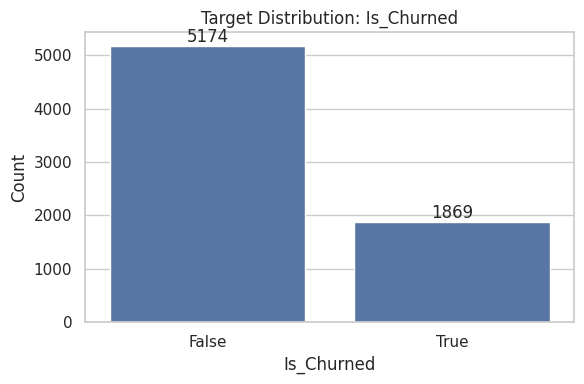

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Is_Churned")
plt.title("Target Distribution: Is_Churned")
plt.xlabel("Is_Churned")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Graph Interpretation

The dataset shows a moderate class imbalance that is expected. So the model evaluation will prioritize recall, F1-score, and ROC-AUC over accuracy to ensure reliable identification of churned customers.

## 5. Business benchmark before modelling

In churn prediction, most customers do not churn, so a model can appear good by always predicting no churn and still achieve high accuracy.
However, this provides no real business value because it fails to identify customers at risk.

A basic benchmark is therefore to assume that every customer will not churn.

This will set the minimum performance level and we expect any useful model must clearly outperform this baseline. Especially in identifying actual churners, otherwise it is not valuable for decision-making.

In [ ]:
majority_class = y.mode()[0] if 'y' in globals() else df['Is_Churned'].mode()[0]
majority_accuracy = (df['Is_Churned'] == majority_class).mean()

benchmark_df = pd.DataFrame({
    "Benchmark Strategy": ["Predict all customers as non-churned"],
    "Predicted Class": [majority_class],
    "Accuracy": [round(majority_accuracy, 4)]
})
benchmark_df

,Benchmark Strategy,Predicted Class,Accuracy
0,Predict all customers as non-churned,False,0.7346


### Why this benchmark matters

The baseline model already achieves around 73% accuracy simply by predicting that no customers churn.

This means that a model reaching 80% accuracy is not necessarily good, because the improvement over the baseline is small.

What really matters is whether the model does a better job at identifying customers who actually churn.
To evaluate this, we focus on:

- how many churners we correctly detect (recall)
- the balance between precision and recall (F1-score)
- how well the model separates churners from non-churners (ROC-AUC)

## 6. Histograms EDA for classification

Based on:
1. Numeric feature distributions
2. Numeric features by churn status
3. Correlation heatmap for numeric variables
4. Churn rate by contract type

We try to visualy verify whether the data contain predictive structure before fitting models.

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "Is_Churned" in numeric_cols:
    numeric_cols.remove("Is_Churned")

bool_cols = [col for col in df.columns if df[col].dtype == bool and col != "Is_Churned"]

print("Numeric columns:", numeric_cols)
print("Boolean columns:", bool_cols[:10], "..." if len(bool_cols) > 10 else "")

Numeric columns: ['Total_Charges', 'Avg_Monthly_Charge', 'Tenure']
Boolean columns: ['Is_Male', 'Is_Senior', 'Is_Married', 'Has_Dependents', 'Has_PhoneService', 'Is_PaperlessBilling', 'Has_OnlineSecurity_No', 'Has_OnlineSecurity_NoInternet', 'Has_OnlineBackup_No', 'Has_OnlineBackup_NoInternet'] ...


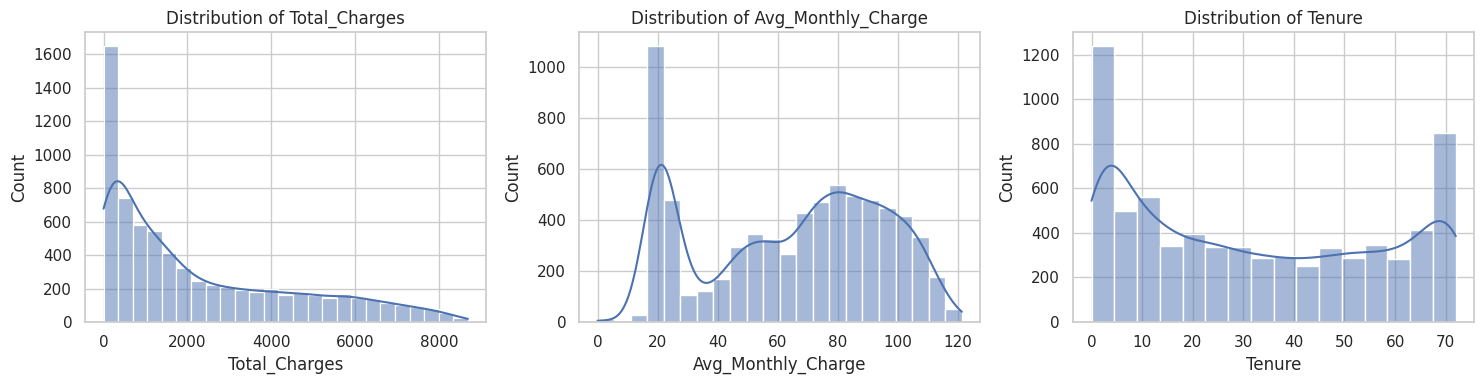

In [ ]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### Expected patterns 1/4

The distributions show that most customers have low total charges and short tenure, while a smaller group consists of long-term, high-value customers.

The inbalanced pattern in monthly charges suggests the presence of different pricing tiers and customer segments.

Together, these patterns indicate that churn is likely driven by customer lifecycle behavior, with higher risk among newer and lower-value customers, while longer tenure customers appear more stable.

This insight is important, as it quickly highlights the need to focus retention efforts on early-stage customers.

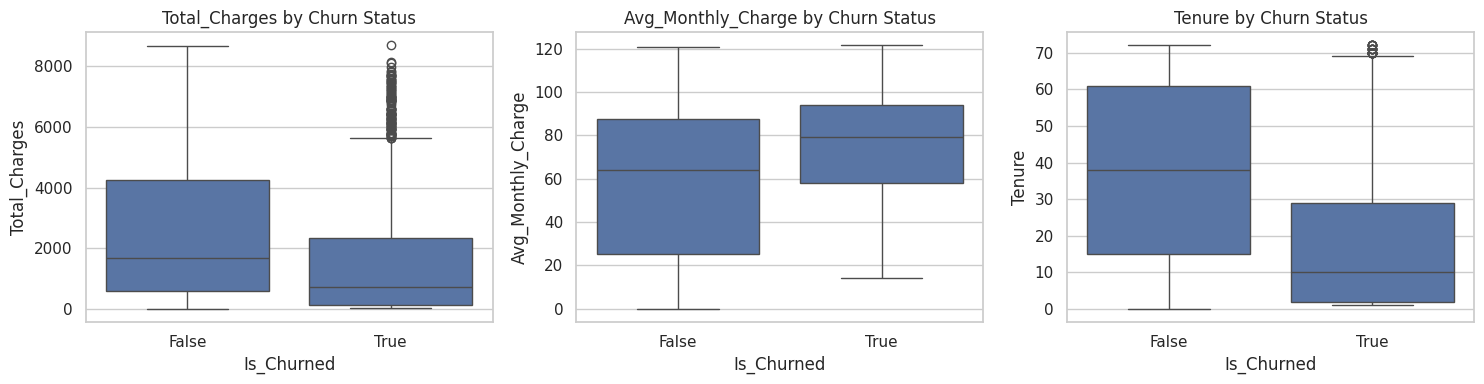

In [ ]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Is_Churned", y=col, ax=ax)
    ax.set_title(f"{col} by Churn Status")

plt.tight_layout()
plt.show()

### Expected patterns 2/4
The boxplots show clear differences between churned and non-churned customers across these key variables.

Customers who churn tend to have significantly lower tenure and lower total charges, indicating they are typically early-stage or less committed users.

At the same time, churned customers exhibit slightly higher monthly charges, suggesting that higher pricing may contribute to churn decisions.

In contrast, long-tenure customers with higher accumulated value appear more stable and less likely to leave.

These patterns confirm that churn is strongly linked to customer lifecycle and perceived value, so we expect the models to learn decision patterns based on variables like

- `Tenure`
- `Total_Charges`
- `Avg_Monthly_Charge`

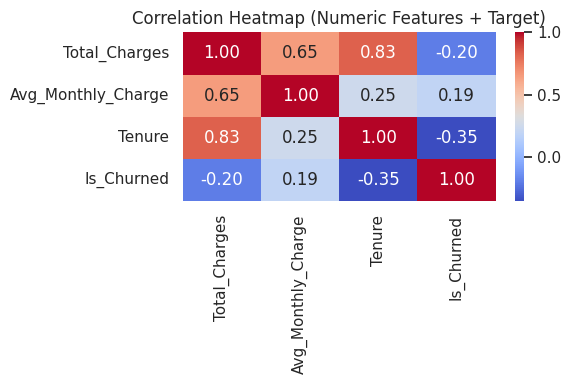

In [ ]:
plt.figure(figsize=(6, 4))
corr = df[numeric_cols + ["Is_Churned"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features + Target)")
plt.tight_layout()
plt.show()

### Expected patterns 3/4
The heatmap also confirms that churn is generally driven by customer lifecycle and value accumulation, rather than pricing alone.

Even though Random Forest and SVM are not limited to linear relationships, this view is still useful for:

- checking redundancy
- understanding feature structure
- supporting the interpretation section in the report
  
We expect the model to rely heavily on tenure as a key predictor, while also leveraging total charges as a proxy for customer loyalty, with monthly charges providing secondary signal for price sensitivity.


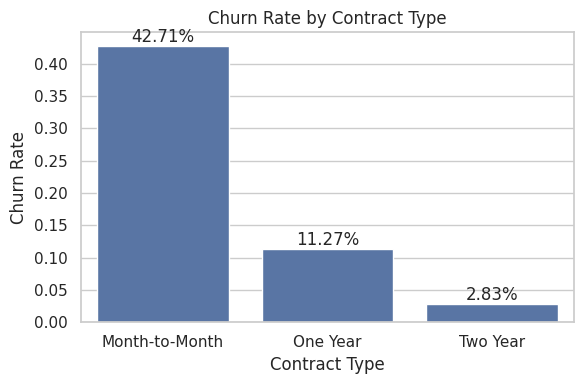

,Contract_Type,Is_Churned
0,Month-to-Month,0.427097
1,One Year,0.112695
2,Two Year,0.028319


In [ ]:
contract_cols = [c for c in df.columns if c.startswith("Is_Contract_")]
if contract_cols:
    contract_churn = df.groupby(contract_cols)["Is_Churned"].mean().reset_index()

    melted = []
    contract_mapping = {
        "Is_Contract_OneYear": "One Year",
        "Is_Contract_TwoYear": "Two Year"
    }

    for _, row in df.iterrows():
        if row.get("Is_Contract_TwoYear", False):
            melted.append("Two Year")
        elif row.get("Is_Contract_OneYear", False):
            melted.append("One Year")
        else:
            melted.append("Month-to-Month")

    plot_df = pd.DataFrame({
        "Contract_Type": melted,
        "Is_Churned": df["Is_Churned"]
    })

    churn_by_contract = (
        plot_df.groupby("Contract_Type")["Is_Churned"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(6, 4))
    ax = sns.barplot(data=churn_by_contract, x="Contract_Type", y="Is_Churned")
    plt.title("Churn Rate by Contract Type")
    plt.ylabel("Churn Rate")
    plt.xlabel("Contract Type")

    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.2%}",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

    display(churn_by_contract)

### Expected patterns 4/4
Contract type is one of the most important business variables in telecom churn.

Based on this visualization, we expect contract type to be one of the strongest predictors of churn, with the model clearly separating high-risk (month-to-month) from low-risk (long-term) customers.

## 7. Prepare features and target

- `X` contains all predictor variables
- `y` contains the target `Is_Churned`

We also convert boolean columns to integers once, so the full feature matrix is numeric and ready for modelling.  

In [ ]:
X = df.drop(columns=["Is_Churned"]).copy()
y = df["Is_Churned"].copy()

# Convert boolean predictors to integers once for modelling
bool_feature_cols = X.select_dtypes(include=["bool"]).columns.tolist()
X[bool_feature_cols] = X[bool_feature_cols].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Feature matrix shape: (7043, 30)
Target shape: (7043,)


,Total_Charges,Avg_Monthly_Charge,Tenure,Is_Male,Is_Senior,Is_Married,Has_Dependents,Has_PhoneService,Is_PaperlessBilling,Has_OnlineSecurity_No,Has_OnlineSecurity_NoInternet,Has_OnlineBackup_No,Has_OnlineBackup_NoInternet,Has_DeviceProtection_No,Has_DeviceProtection_NoInternet,Has_TechSupport_No,Has_TechSupport_NoInternet,Has_StreamingTV_No,Has_StreamingTV_NoInternet,Has_StreamingMovies_No,Has_StreamingMovies_NoInternet,Has_MultipleLines_No,Has_MultipleLines_NoPhone,Is_InternetService_FiberOptic,Is_InternetService_None,Is_Contract_OneYear,Is_Contract_TwoYear,Is_PaymentMethod_CreditCard,Is_PaymentMethod_ElectronicCheck,Is_PaymentMethod_MailedCheck
0,29.85,29.85,1,0,0,1,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,1,0
1,1889.50,55.57,34,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,1
2,108.15,54.08,2,1,0,0,0,1,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,1
3,1840.75,40.91,45,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0
4,151.65,75.82,2,0,0,0,0,1,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0


## 8. Train/test split - stratified

We use a stratified train/test split so that the churn proportion remains approximately the same in both subsets.

This is important because a non-stratified split can distort the class balance, especially in churn problems where the positive class is smaller.

We believe that a 70/30 is a practical split, with enough data for the model to learn, as well as to evaluate reliably.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
display(y_train.value_counts(normalize=True).rename("proportion").to_frame())
print("y_test distribution:")
display(y_test.value_counts(normalize=True).rename("proportion").to_frame())

X_train: (4930, 30)
X_test : (2113, 30)
y_train distribution:


,proportion
Is_Churned,
False,0.734686
True,0.265314


y_test distribution:


,proportion
Is_Churned,
False,0.734501
True,0.265499


## 9. Create shared evaluation utilities

The same evaluation logic should be applied consistently in all models.

To avoid repetition, we define helper functions once and then reuse them for:

- baseline Random Forest
- tuned Random Forest
- baseline SVM
- tuned SVM


In [ ]:
def get_classification_metrics(model, X_train, X_test, y_train, y_test, model_name):

    # Fits a model
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Use scores for ROC-AUC if available
    if hasattr(model, "predict_proba"):
        y_test_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_test_score = model.decision_function(X_test)
    else:
        y_test_score = y_test_pred.astype(int)

    # Returns a metrics dictionary
    metrics_dict = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, pos_label=True),
        "Recall": recall_score(y_test, y_test_pred, pos_label=True),
        "F1-score": f1_score(y_test, y_test_pred, pos_label=True),
        "ROC-AUC": roc_auc_score(y_test.astype(int), y_test_score)
    }

    return metrics_dict, y_test_pred, y_test_score


def display_results(model, X_test, y_test, y_pred, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[False, True])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[False, True])
    disp.plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"{model_name} - Confusion Matrix")

    # ROC curve
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
    axes[1].set_title(f"{model_name} - ROC Curve")

    plt.tight_layout()
    plt.show()

    # Classification report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred, digits=4))

### Why F1-score is used as the main tuning metric

It should be stated that, `RandomizedSearchCV` uses **scoring="f1"** for both models because F1-score gives a more balanced view of business usefulness since:

- **Precision** matters because we do not want to overwhelm the retention team with too many false alarms.
- **Recall** matters because missing real churners is costly.
- **F1-score** balances both, making it a strong primary optimization target for churn outreach use cases.

Accuracy, recall, and ROC-AUC are still reported separately so the final model decision is based on a complete picture, not on one metric alone.

### Hyperparameter Interpretation

For Random Forest:
- `n_estimators`: number of trees (more trees → more stable model)
- `max_depth`: controls tree complexity (prevents overfitting)
- `min_samples_split` / `min_samples_leaf`: control how easily trees split (reduce noise)

For SVM:
- `C`: controls trade-off between margin and classification errors
- `gamma`: controls how complex the decision boundary is

In [ ]:
def explain_selected_params(model_family, best_params):

    """Business-friendly explanation table for the selected hyperparameters."""
    explanations = {
        "rf": {
            "n_estimators": "More trees → more stable",
            "max_depth": "Controls tree complexity",
            "min_samples_split": "Prevents early splitting",
            "min_samples_leaf": "Reduces overfitting noise",
            "max_features": "Controls feature randomness",
            "bootstrap": "Enables bagging diversity"
        },
        "svm": {
            "svm__C": "Penalty strength for errors",
            "svm__gamma": "Controls boundary complexity"
        }
    }

    rows = []
    family_explanations = explanations[model_family]
    for param, value in best_params.items():
        rows.append({
            "Parameter": param,
            "Selected Value": value,
            "Why it matters": family_explanations.get(param, "Tuning parameter")
        })
    return pd.DataFrame(rows)

## 10. Baseline Model 1 - Random Forest

We start with a **baseline Random Forest** using standard settings.

### Why Random Forest was used
Random Forest is a strong choice for this dataset because:

- it handles tabular data very well
- it captures nonlinear interactions
- it is robust to noise and mixed feature behavior
- it can rank variables through feature importance

For the baseline version, we keep the model simple so that we can later compare it to the tuned version fairly.

In [ ]:
rf_baseline = RandomForestClassifier(
    random_state=RANDOM_STATE
)

rf_baseline_metrics, rf_baseline_pred, rf_baseline_score = get_classification_metrics(
    rf_baseline, X_train, X_test, y_train, y_test, "Random Forest Baseline"
)

rf_baseline_results = pd.DataFrame([rf_baseline_metrics]).round(4)
rf_baseline_results

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest Baseline,0.998,0.7894,0.6355,0.4848,0.5501,0.8216


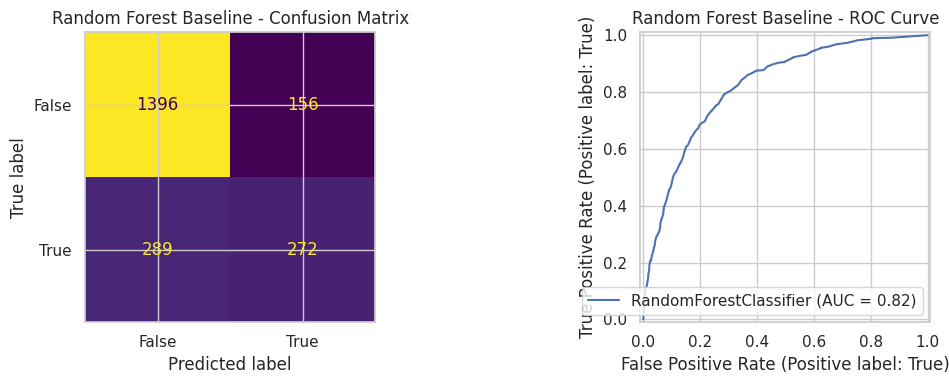

Classification Report for Random Forest Baseline:
              precision    recall  f1-score   support

       False     0.8285    0.8995    0.8625      1552
        True     0.6355    0.4848    0.5501       561

    accuracy                         0.7894      2113
   macro avg     0.7320    0.6922    0.7063      2113
weighted avg     0.7773    0.7894    0.7796      2113



In [ ]:
display_results(rf_baseline, X_test, y_test, rf_baseline_pred, "Random Forest Baseline")

### Baseline Random Forest interpretation
The baseline model gives us a solid first reference point.

Overall accuracy is ~79%, which is only moderately above the majority-class benchmark of ~73%, indicating limited improvement in overall prediction.

The model performs well on non-churners (recall ~90%), but struggles with churners (recall ~48%), meaning many churn cases are missed.

The ROC-AUC (~0.82) shows good ranking ability, suggesting the model can distinguish churn risk even if classification threshold limits recall.

All in all, while the model captures general patterns, it needs improvement in detecting churners.

## 11. Tune Model 1 - Random Forest with RandomizedSearchCV

Hyperparameter tuning is needed because Random Forest performance depends heavily on:

- number of trees
- maximum tree depth
- minimum samples required to split
- minimum samples per leaf
- number of features considered at each split

We use **RandomizedSearchCV** instead of exhaustive grid search because it is computationally more efficient while still exploring a strong region of the parameter space.

### Why these Random Forest parameters were searched

The search space focuses on:

- `n_estimators`: tested across a moderate-to-large range because more trees usually improve stability
- `max_depth`: included both restricted and unrestricted values to test underfitting vs overfitting
- `min_samples_split` and `min_samples_leaf`: included to control how aggressively the trees grow
- `max_features`: varied because tree diversity is important in a forest
- `bootstrap`: tested because bagging behavior can affect generalization

This search space balances model flexibility and generalization, allowing the model to explore different complexity levels while maintaining stability and avoiding overfitting.

In [ ]:
rf_param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=25,
    scoring="f1",
    cv=rf_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("Best RF parameters:")
display(rf_random_search.best_params_)
print("Best RF CV score (F1):", round(rf_random_search.best_score_, 4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best RF parameters:


{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 6,
 'max_features': 'log2',
 'max_depth': 15,
 'bootstrap': True}

Best RF CV score (F1): 0.5777


In [ ]:
rf_tuned = rf_random_search.best_estimator_

rf_tuned_metrics, rf_tuned_pred, rf_tuned_score = get_classification_metrics(
    rf_tuned, X_train, X_test, y_train, y_test, "Random Forest Tuned"
)

rf_tuned_results = pd.DataFrame([rf_tuned_metrics]).round(4)
rf_tuned_results

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest Tuned,0.8444,0.7984,0.6675,0.4795,0.5581,0.8416


In [ ]:
rf_best_params_explained = explain_selected_params("rf", rf_random_search.best_params_)
rf_best_params_explained

,Parameter,Selected Value,Why it matters
0,n_estimators,100,More trees → more stable
1,min_samples_split,2,Prevents early splitting
2,min_samples_leaf,6,Reduces overfitting noise
3,max_features,log2,Controls feature randomness
4,max_depth,15,Controls tree complexity
5,bootstrap,True,Enables bagging diversity


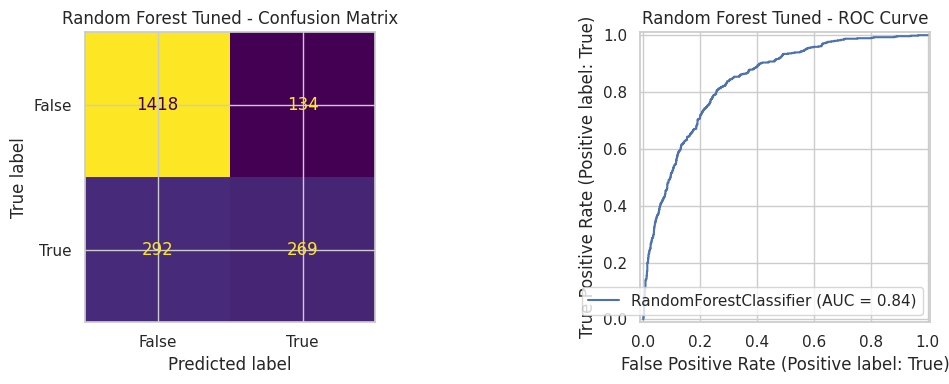

Classification Report for Random Forest Tuned:
              precision    recall  f1-score   support

       False     0.8292    0.9137    0.8694      1552
        True     0.6675    0.4795    0.5581       561

    accuracy                         0.7984      2113
   macro avg     0.7484    0.6966    0.7137      2113
weighted avg     0.7863    0.7984    0.7868      2113



In [ ]:
display_results(rf_tuned, X_test, y_test, rf_tuned_pred, "Random Forest Tuned")

### Compare baseline vs tuned Random Forest


In [ ]:
rf_comparison = pd.concat([rf_baseline_results, rf_tuned_results], ignore_index=True)
rf_comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest Baseline,0.9980,0.7894,0.6355,0.4848,0.5501,0.8216
1,Random Forest Tuned,0.8444,0.7984,0.6675,0.4795,0.5581,0.8416


The tuned model shows small yet improvements over the baseline in all metrics.

But most importantly, the baseline model shows severe overfitting (train 0.9980 vs test 0.7894), while the tuned model significantly reduces this gap (0.8444 vs 0.7984), demonstrating improved generalization.

## 12. Baseline Model 2 - SVM with RBF kernel

### Why SVM was used
SVM is appropriate here because:

- it is powerful for nonlinear classification
- it performs well on small-medium structured datasets
- the RBF kernel can model curved decision boundaries

### Why a pipeline was used
SVM is sensitive to feature scale, so scaling must be applied before the classifier.

To avoid data leakage, we place the scaler and classifier inside a single `Pipeline`.  
That way, scaling is fit only on the training folds during training and tuning.

In [ ]:
svm_baseline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

svm_baseline_metrics, svm_baseline_pred, svm_baseline_score = get_classification_metrics(
    svm_baseline, X_train, X_test, y_train, y_test, "SVM RBF Baseline"
)

svm_baseline_results = pd.DataFrame([svm_baseline_metrics]).round(4)
svm_baseline_results

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM RBF Baseline,0.7673,0.7402,0.5069,0.7807,0.6147,0.8199


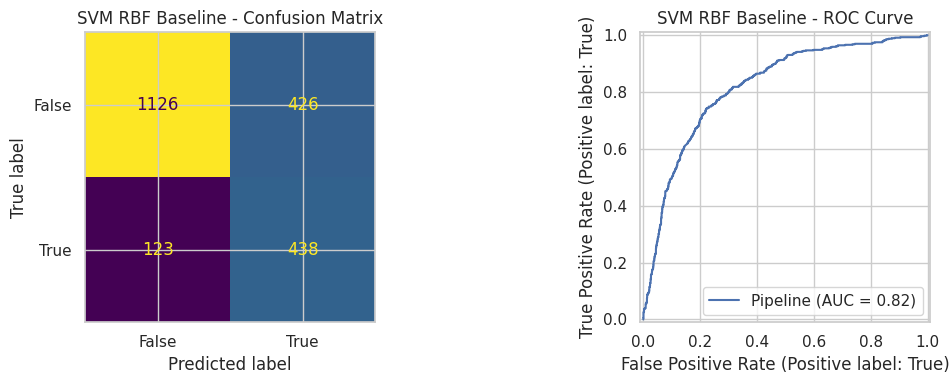

Classification Report for SVM RBF Baseline:
              precision    recall  f1-score   support

       False     0.9015    0.7255    0.8040      1552
        True     0.5069    0.7807    0.6147       561

    accuracy                         0.7402      2113
   macro avg     0.7042    0.7531    0.7094      2113
weighted avg     0.7968    0.7402    0.7537      2113



In [ ]:
display_results(svm_baseline, X_test, y_test, svm_baseline_pred, "SVM RBF Baseline")

### Baseline SVM vs Baseline RF
The baseline SVM shows a different behavior compared to Random Forest, prioritizing churn detection over overall accuracy.

The SVM is more effective at detecting churners compared to Random Forest (recall ~78 vs ~48%), but at the cost of over-predicting churn (precision: ~51 vs ~64), which may lead to unnecessary business actions.
This reflects a trade-off between recall and precision, where the model favors capturing as many churners as possible.

## 13. Tuned Model 2 - SVM (RBF) with RandomizedSearchCV

For SVM, the most important hyperparameters are:

- `C` → controls the penalty for misclassification
- `gamma` → controls how far the influence of each observation reaches in the RBF kernel

These two parameters strongly affect the bias–variance trade-off, that is why the search range spans both small and large values, allowing the notebook to test smoother boundaries against more flexible ones.

In [ ]:
svm_param_dist = {
    "svm__C": [0.01, 0.1, 1, 5, 10, 20, 50, 100],
    "svm__gamma": ["scale", 1, 0.1, 0.01, 0.001, 0.0001]
}

svm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_random_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),
    param_distributions=svm_param_dist,
    n_iter=20,
    scoring="f1",
    cv=svm_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

svm_random_search.fit(X_train, y_train)

print("Best SVM parameters:")
display(svm_random_search.best_params_)
print("Best SVM CV score (F1):", round(svm_random_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best SVM parameters:


{'svm__gamma': 0.1, 'svm__C': 0.1}

Best SVM CV score (F1): 0.6219


In [ ]:
svm_tuned = svm_random_search.best_estimator_

svm_tuned_metrics, svm_tuned_pred, svm_tuned_score = get_classification_metrics(
    svm_tuned, X_train, X_test, y_train, y_test, "SVM RBF Tuned"
)

svm_tuned_results = pd.DataFrame([svm_tuned_metrics]).round(4)
svm_tuned_results

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM RBF Tuned,0.7753,0.744,0.5122,0.7504,0.6088,0.8175


In [ ]:
svm_best_params_explained = explain_selected_params("svm", svm_random_search.best_params_)
svm_best_params_explained

,Parameter,Selected Value,Why it matters
0,svm__gamma,0.1,Controls boundary complexity
1,svm__C,0.1,Penalty strength for errors


### Why the selected SVM parameters make sense

With these parameters (C = 0.1, gamma = 0.1) the model maintains high recall (0.75) for churners while keeping performance stable, although precision remains moderate (0.51). This indicates the model prioritizes capturing churners while avoiding overfitting.

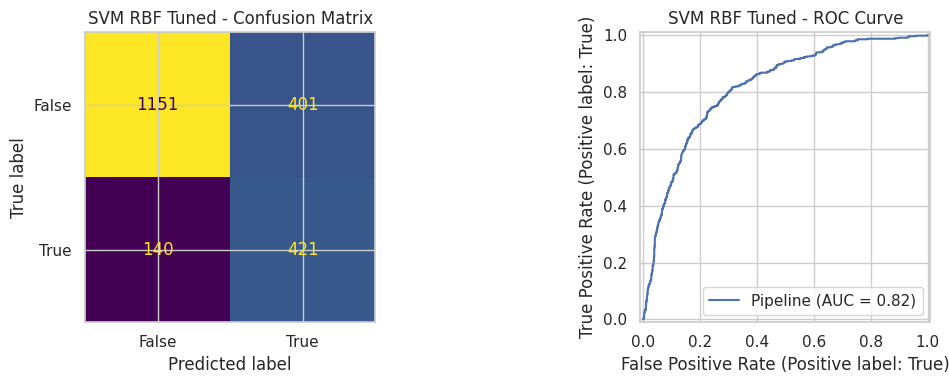

Classification Report for SVM RBF Tuned:
              precision    recall  f1-score   support

       False     0.8916    0.7416    0.8097      1552
        True     0.5122    0.7504    0.6088       561

    accuracy                         0.7440      2113
   macro avg     0.7019    0.7460    0.7093      2113
weighted avg     0.7908    0.7440    0.7564      2113



In [ ]:
display_results(svm_tuned, X_test, y_test, svm_tuned_pred, "SVM RBF Tuned")

### Compare baseline vs tuned SVM

In [ ]:
svm_comparison = pd.concat([svm_baseline_results, svm_tuned_results], ignore_index=True)
svm_comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM RBF Baseline,0.7673,0.7402,0.5069,0.7807,0.6147,0.8199
1,SVM RBF Tuned,0.7753,0.7440,0.5122,0.7504,0.6088,0.8175


Tuning has minimal impact on performance, slightly improving precision but reducing recall, which weakens churn detection. This suggests the baseline SVM was already near its optimal performance under the current setup.

### Feature importance interpretation

The feature importance results show that contract type and service-related variables are the strongest drivers of churn prediction.

This is a really useful insight that is trying to prevent in general the SVM from becoming a black box.

## 14. Final tuned model comparison

In [ ]:
final_comparison = pd.concat([rf_tuned_results, svm_tuned_results], ignore_index=True)
final_comparison = final_comparison.sort_values("F1-score", ascending=False).reset_index(drop=True)
final_comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM RBF Tuned,0.7753,0.7440,0.5122,0.7504,0.6088,0.8175
1,Random Forest Tuned,0.8444,0.7984,0.6675,0.4795,0.5581,0.8416


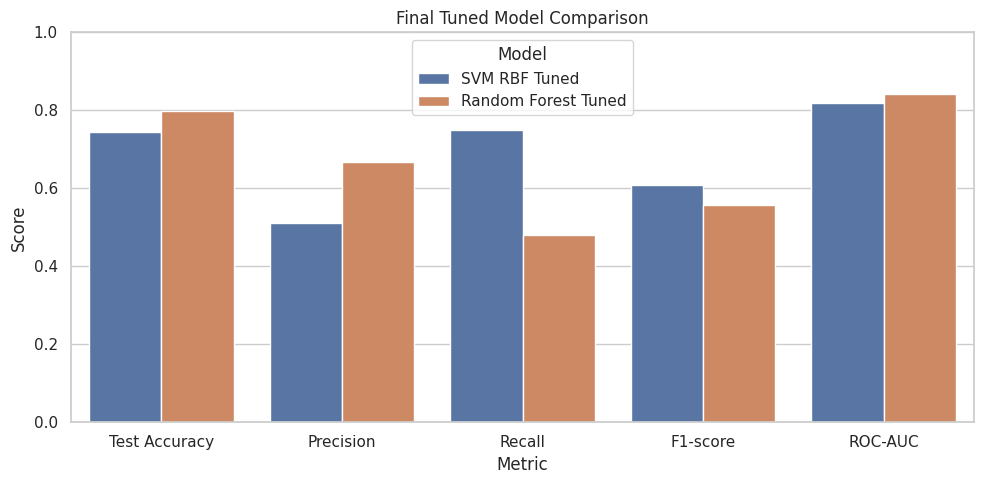

In [ ]:
comparison_melted = final_comparison.melt(
    id_vars="Model",
    value_vars=["Test Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model")
plt.title("Final Tuned Model Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Final model comparison and selection

The two tuned models show different strengths:

- **SVM RBF Tuned** achieves higher recall (0.75) and F1-score (0.61), meaning it is better at identifying churners  
- **Random Forest Tuned** achieves higher accuracy (0.80), precision (0.67), and ROC-AUC (0.84), meaning it is more precise and better at ranking customers  

From a business perspective, churn prediction prioritizes identifying customers at risk, even if it includes some false positives. Missing churners is more costly than targeting a few extra customers.

Therefore, SVM RBF Tuned is the more optimal model, as it captures significantly more churners (recall 0.75 vs 0.48), making it more suitable for retention strategies.


In [ ]:
best_model_name = final_comparison.loc[0, "Model"]
best_f1 = final_comparison.loc[0, "F1-score"]
best_recall = final_comparison.loc[0, "Recall"]
best_auc = final_comparison.loc[0, "ROC-AUC"]

print(f"Best final model based on F1-score: {best_model_name}")
print(f"F1-score: {best_f1:.4f}")
print(f"Recall  : {best_recall:.4f}")
print(f"ROC-AUC : {best_auc:.4f}")

Best final model based on F1-score: SVM RBF Tuned
F1-score: 0.6088
Recall  : 0.7504
ROC-AUC : 0.8175


## 15.1. Random Forest feature importance

One advantage of Random Forest is that it provides direct feature importance values, which helps us answer:

> Which customer characteristics are most associated with churn?

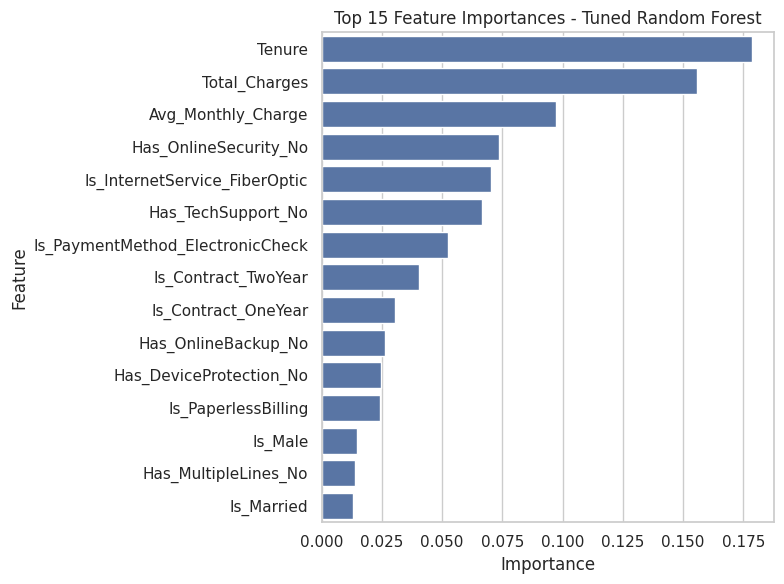

,Feature,Importance
2,Tenure,0.178740
0,Total_Charges,0.155744
1,Avg_Monthly_Charge,0.097234
9,Has_OnlineSecurity_No,0.073733
23,Is_InternetService_FiberOptic,0.070475
15,Has_TechSupport_No,0.066396
28,Is_PaymentMethod_ElectronicCheck,0.052413
26,Is_Contract_TwoYear,0.040398
25,Is_Contract_OneYear,0.030270
11,Has_OnlineBackup_No,0.026349


In [ ]:
rf_importances = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf_tuned.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importances, x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - Tuned Random Forest")
plt.tight_layout()
plt.show()

rf_importances

## 15.2 Permutation importance for tuned SVM

Unlike Random Forest, SVM does not provide built-in feature importance.

This method measures how much the model’s performance (F1-score) decreases when a feature is randomly shuffled.

Higher importance indicates that the feature plays a stronger role in predicting churn across the dataset.

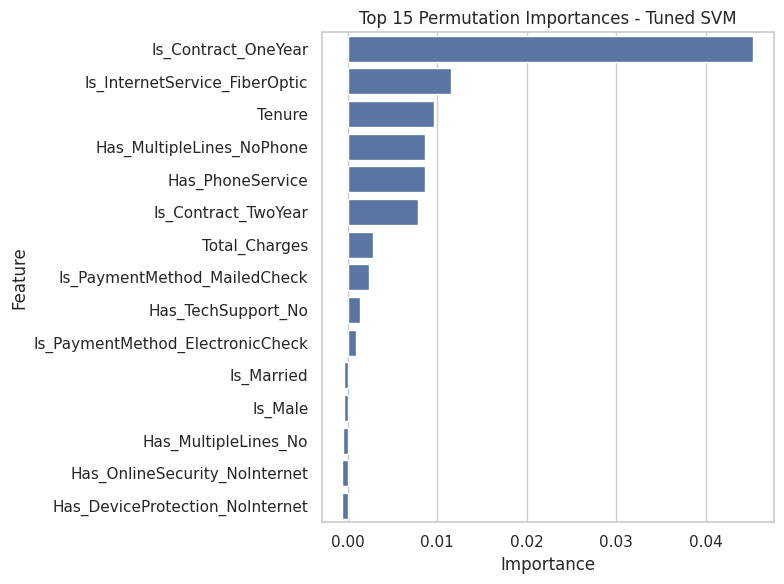

,Feature,Importance
25,Is_Contract_OneYear,0.045356
23,Is_InternetService_FiberOptic,0.011589
2,Tenure,0.009630
22,Has_MultipleLines_NoPhone,0.008602
7,Has_PhoneService,0.008602
26,Is_Contract_TwoYear,0.007813
0,Total_Charges,0.002807
29,Is_PaymentMethod_MailedCheck,0.002368
15,Has_TechSupport_No,0.001324
28,Is_PaymentMethod_ElectronicCheck,0.000939


In [ ]:
svm_perm = permutation_importance(
    svm_tuned,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1
)

svm_importances = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": svm_perm.importances_mean
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(data=svm_importances, x="Importance", y="Feature")
plt.title("Top 15 Permutation Importances - Tuned SVM")
plt.tight_layout()
plt.show()

svm_importances

### 16. SHAP Feature Importance

To better understand how the models make predictions, we initially considered using SHAP, a popular explainability method for black-box models such as Random Forest and especially SVM. SHAP provides detailed insights into feature contributions, but in practice it proved to be computationally expensive, particularly for the SVM model, where it relies on slower model-agnostic approximations.

This is the reason, we instead used permutation importance, which offers a more efficient and still reliable way to assess feature influence.

While less granular than SHAP, permutation importance is well suited for comparing feature importance across models and aligns better with the computational constraints of the dataset.

PermutationExplainer explainer: 2114it [06:37,  5.23it/s]


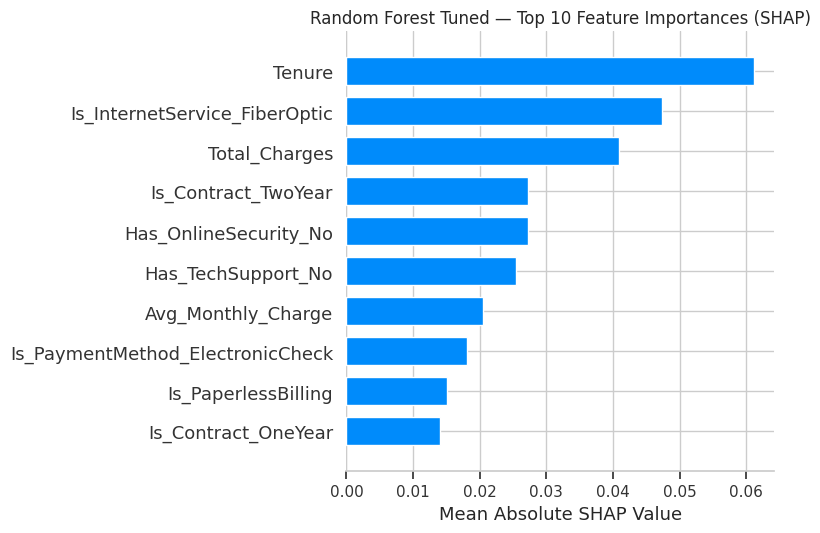

In [ ]:
import shap

explainer = shap.Explainer(rf_tuned.predict_proba, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", max_display=10, show=False)
plt.title("Random Forest Tuned — Top 10 Feature Importances (SHAP)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

In [ ]:
import shap

explainer = shap.Explainer(svm_tuned.predict_proba, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", max_display=10, show=False)
plt.title("SVM RBF Tuned — Top 10 Feature Importances (SHAP)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

PermutationExplainer explainer:  43%|████▎     | 915/2113 [1:16:48<1:57:20,  5.88s/it]

## 17. Summary

This notebook developed and evaluated two optimized classification models for customer churn prediction:

- **Random Forest**
- **SVM with RBF kernel**

Both models were first tested in baseline form and then improved using RandomizedSearchCV.  
The final comparison was based on Accuracy, Precision, Recall, F1-score and ROC-AUC so that the results were depicted correctly and not reduced to accuracy alone.

SVM tuned model was chosen as the best one.